In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
data = pd.read_csv(url)

In [3]:
# Separate features and target
X = data.drop('species', axis=1)
y = data['species']

In [4]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Standardize features for KNN
scaler = StandardScaler()

In [6]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Create models
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
knn_model = KNeighborsClassifier(n_neighbors=5)

In [8]:
# Train models
dt_model.fit(X_train, y_train)
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_scaled)


In [10]:
# Decision Tree Results
print("\nDecision Tree Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt) * 100, 2), "%")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Results:
Accuracy: 100.0 %
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
# KNN Results
print("\nKNN Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_knn) * 100, 2), "%")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Results:
Accuracy: 100.0 %
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
dt_accuracy = accuracy_score(y_test, y_pred_dt) * 100
knn_accuracy = accuracy_score(y_test, y_pred_knn) * 100

print("\nModel Accuracy Comparison:")
print("Decision Tree:", round(dt_accuracy, 2), "%")
print("KNN:", round(knn_accuracy, 2), "%")


Model Accuracy Comparison:
Decision Tree: 100.0 %
KNN: 100.0 %


In [13]:
# Example flower measurements
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Decision Tree prediction
dt_prediction = dt_model.predict(new_flower)

# KNN prediction needs scaling
new_flower_scaled = scaler.transform(new_flower)
knn_prediction = knn_model.predict(new_flower_scaled)

print("\nPrediction for New Flower:")
print("Decision Tree:", dt_prediction[0])
print("KNN:", knn_prediction[0])


Prediction for New Flower:
Decision Tree: setosa
KNN: setosa


C:\Users\sumed\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\sumed\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [14]:
print("\nDecision Tree Feature Importance:")

for feature, importance in zip(X.columns, dt_model.feature_importances_):
    print(feature, ":", round(importance, 4))


Decision Tree Feature Importance:
sepal_length : 0.0
sepal_width : 0.0145
petal_length : 0.8954
petal_width : 0.0901


In [15]:
print("\nKNN Accuracy for Different K Values:")

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    prediction = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, prediction) * 100

    print("K =", k, "Accuracy =", round(accuracy, 2), "%")


KNN Accuracy for Different K Values:
K = 1 Accuracy = 100.0 %
K = 2 Accuracy = 100.0 %
K = 3 Accuracy = 100.0 %
K = 4 Accuracy = 100.0 %
K = 5 Accuracy = 100.0 %
K = 6 Accuracy = 100.0 %
K = 7 Accuracy = 100.0 %
K = 8 Accuracy = 100.0 %
K = 9 Accuracy = 100.0 %
K = 10 Accuracy = 100.0 %


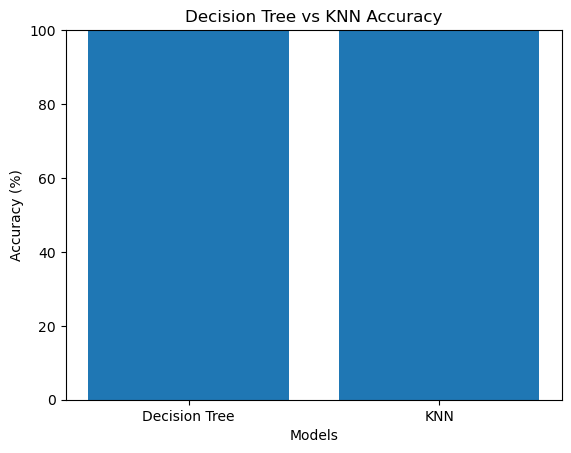

In [16]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'KNN']
accuracies = [dt_accuracy, knn_accuracy]

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Decision Tree vs KNN Accuracy")
plt.ylim(0, 100)

plt.show()